# Network Intrusion Detection: Benign vs. Malicious Traffic Classifier

This notebook trains and evaluates machine learning models that classify network flows as **Benign** or **Malicious** using the **CIC-IDS2017** dataset.

### A note on "malware" vs. "network intrusion detection"
The CIC-IDS2017 dataset does not contain malware binaries or files. It contains **network flow statistics** (packet sizes, timing, flag counts, etc.) captured while various attacks were run against a test network: DoS/DDoS floods, port scans, brute-force logins, web attacks (SQLi/XSS), a botnet, and an infiltration. This is exactly what a **Network Intrusion Detection System (NIDS)** looks at, and it is the standard proxy dataset for "is this traffic benign or an attack" classification. So we'll treat every non-BENIGN flow as **malicious/attack traffic** — conceptually the same binary task as "benign vs. malware", just at the network-flow level rather than the file level.

### What this notebook produces
1. A cleaned, combined dataset from all 8 raw capture files
2. Exploratory look at the class balance
3. Three trained models (Logistic Regression, Random Forest, XGBoost) so we can **compare** approaches
4. Evaluation metrics, confusion matrices, and ROC/PR curves for each model
5. A model comparison table
6. Feature importance and SHAP explainability plots for the best model
7. Example predictions with confidence/risk scores
8. The trained model saved to disk for reuse

## 1. Setup

In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

## 2. Load and combine the raw capture files

Each CSV is one day's worth of captured flows (already converted from `.pcap` to flow features by CICFlowMeter). We load all 8, strip stray whitespace from column names (the raw files have leading spaces in headers), and concatenate them into one dataset.

In [2]:
t0 = time.time()
frames = []
for f in sorted(DATA_DIR.glob("*.csv")):
    d = pd.read_csv(f, encoding="utf-8", low_memory=False)
    d.columns = d.columns.str.strip()
    frames.append(d)
    print(f"{f.name:55s} {d.shape}")

df = pd.concat(frames, ignore_index=True)
del frames
print(f"\nCombined shape: {df.shape}  ({time.time() - t0:.1f}s)")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB")

Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv        (225745, 79)
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv    (286467, 79)
Friday-WorkingHours-Morning.pcap_ISCX.csv               (191033, 79)
Monday-WorkingHours.pcap_ISCX.csv                       (529918, 79)
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv (288602, 79)
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  (170366, 79)
Tuesday-WorkingHours.pcap_ISCX.csv                      (445909, 79)
Wednesday-workingHours.pcap_ISCX.csv                    (692703, 79)

Combined shape: (2830743, 79)  (47.2s)
Memory usage: 1923 MB


## 3. Clean the data

Real-world flow exports like this have a few known issues we need to handle before modeling:

- **Mangled label text**: the Thursday web-attack file has a `�` replacement character in place of an en-dash (an artifact of how the original dataset was distributed). We normalize it to a plain hyphen for readability.
- **Infinite values**: `Flow Bytes/s` and `Flow Packets/s` are computed by dividing by `Flow Duration`, which is occasionally `0`, producing `inf`. We convert those to `NaN` and drop the affected rows (a tiny fraction of the data).
- **Duplicate rows**: CIC-IDS2017 is known to contain a large number of exact duplicate flows across files. We drop them so the model isn't trained (and evaluated) on repeated examples, which would bias both training and our metrics.
- **Memory**: we downcast numeric columns to `float32` since we don't need `float64` precision for these features, roughly halving memory usage.

In [3]:
df["Label"] = df["Label"].str.replace("�", "-", regex=False).str.strip()

num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].astype("float32")

df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
n_before = len(df)
df = df.dropna(subset=num_cols)
print(f"Dropped {n_before - len(df):,} rows with inf/NaN values ({(n_before - len(df)) / n_before:.3%})")

n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {n_before - len(df):,} duplicate rows ({(n_before - len(df)) / n_before:.1%})")

print(f"\nFinal cleaned shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB")

Dropped 2,867 rows with inf/NaN values (0.101%)
Dropped 329,896 duplicate rows (11.7%)

Final cleaned shape: (2497980, 79)
Memory usage: 917 MB


## 4. Exploratory analysis: class balance

Before building the binary target, it's worth seeing the original attack-type breakdown — this is what's actually hiding inside "malicious traffic".

Label
BENIGN                        2072254
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10282
FTP-Patator                      5931
DoS slowloris                    5374
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack - Brute Force         1470
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


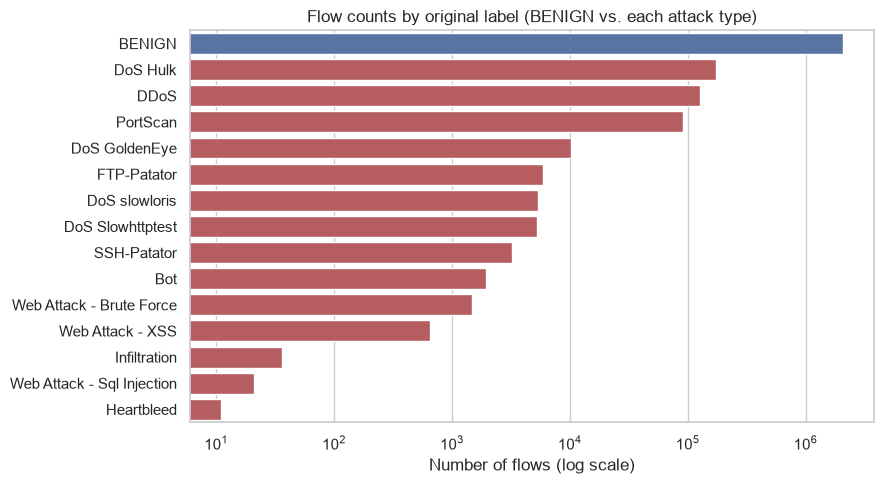

In [4]:
label_counts = df["Label"].value_counts()
print(label_counts)

fig, ax = plt.subplots(figsize=(9, 5))
order = label_counts.index
colors = ["#4C72B0" if l == "BENIGN" else "#C44E52" for l in order]
sns.barplot(x=label_counts.values, y=order, hue=order, palette=colors, legend=False, ax=ax)
ax.set_xscale("log")
ax.set_xlabel("Number of flows (log scale)")
ax.set_ylabel("")
ax.set_title("Flow counts by original label (BENIGN vs. each attack type)")
plt.tight_layout()
plt.show()

## 5. Build the binary target

`Attack` = 0 for `BENIGN`, 1 for anything else (DDoS, PortScan, brute force, web attacks, bot, infiltration). This is our "benign vs. malware/malicious" label. The classes are imbalanced (roughly 80/20), which is realistic for network traffic — most traffic is normal — so we'll use class-weighting during training and rely on precision/recall/ROC-AUC (not just accuracy) for evaluation.

Label
Benign       0.829572
Malicious    0.170428
Name: proportion, dtype: float64


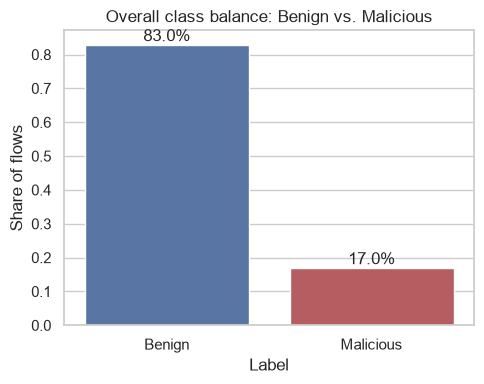


Feature matrix shape: (2497980, 78)


In [5]:
CLASS_NAMES = ["Benign", "Malicious"]

y = (df["Label"] != "BENIGN").astype(int)
X = df.drop(columns=["Label"])

balance = y.value_counts(normalize=True).rename(index={0: "Benign", 1: "Malicious"})
print(balance)

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=balance.index, y=balance.values, hue=balance.index,
            palette=["#4C72B0", "#C44E52"], legend=False, ax=ax)
ax.set_ylabel("Share of flows")
ax.set_title("Overall class balance: Benign vs. Malicious")
for i, v in enumerate(balance.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.show()

print(f"\nFeature matrix shape: {X.shape}")

## 6. Train/test split and preprocessing

We hold out 20% of the data as a test set, **stratified** by the target so both splits keep the same ~80/20 class ratio. We fit a `StandardScaler` on the training data only (to avoid leaking test-set statistics). This is needed for Logistic Regression, which is sensitive to feature scale. Tree-based models (Random Forest, XGBoost) are scale-invariant, so they use the unscaled features directly.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True)}")

Train: (1998384, 78), Test: (499596, 78)
Train class balance:
Label
0    0.829572
1    0.170428
Name: proportion, dtype: float64


## 7. Train three models

We train three models spanning three different approaches, so the comparison later is meaningful rather than arbitrary:

| Model | Type | Why include it |
|---|---|---|
| Logistic Regression | Linear | Fast, interpretable baseline — tells us if the problem is even close to linearly separable |
| Random Forest | Bagged decision trees | Strong general-purpose baseline, robust to feature scale/outliers, gives feature importances |
| XGBoost | Gradient-boosted trees | Usually the strongest performer on tabular data like this; also gives feature importances and works with SHAP |

Each model uses **class weighting** to compensate for the 80/20 imbalance instead of resampling the data.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

trained = {}  # name -> dict(model, uses_scaled, y_pred, y_proba, train_time)


def train_and_predict(name, model, uses_scaled):
    Xtr = X_train_scaled if uses_scaled else X_train
    Xte = X_test_scaled if uses_scaled else X_test

    t0 = time.time()
    model.fit(Xtr, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    trained[name] = dict(
        model=model, uses_scaled=uses_scaled,
        y_pred=y_pred, y_proba=y_proba, train_time=train_time,
    )
    print(f"{name}: trained in {train_time:.1f}s")

In [8]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
train_and_predict("Logistic Regression", log_reg, uses_scaled=True)

Logistic Regression: trained in 73.0s


In [9]:
rand_forest = RandomForestClassifier(
    n_estimators=200, class_weight="balanced_subsample",
    n_jobs=-1, random_state=RANDOM_STATE,
)
train_and_predict("Random Forest", rand_forest, uses_scaled=False)

Random Forest: trained in 1417.1s


In [10]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # balances XGBoost the way class_weight does for sklearn

xgb_clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
)
train_and_predict("XGBoost", xgb_clf, uses_scaled=False)

XGBoost: trained in 515.3s


## 8. Evaluation metrics per model

For each model we compute:
- **Accuracy** — overall correctness (least informative here, since the classes are imbalanced)
- **Precision** — of the flows we flagged as malicious, how many actually were (low precision = too many false alarms)
- **Recall** — of the actually malicious flows, how many we caught (low recall = attacks slipping through)
- **F1** — harmonic mean of precision/recall, a single balanced score
- **ROC-AUC** — how well the model's confidence scores separate the two classes across all thresholds

In [11]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve,
)

metrics_rows = []
for name, info in trained.items():
    y_pred, y_proba = info["y_pred"], info["y_proba"]
    metrics_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "Train time (s)": info["train_time"],
    })
    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

=== Logistic Regression ===
              precision    recall  f1-score   support

      Benign     0.9948    0.9325    0.9627    414451
   Malicious     0.7483    0.9762    0.8472     85145

    accuracy                         0.9400    499596
   macro avg     0.8715    0.9544    0.9049    499596
weighted avg     0.9528    0.9400    0.9430    499596

=== Random Forest ===
              precision    recall  f1-score   support

      Benign     0.9990    0.9992    0.9991    414451
   Malicious     0.9962    0.9951    0.9957     85145

    accuracy                         0.9985    499596
   macro avg     0.9976    0.9972    0.9974    499596
weighted avg     0.9985    0.9985    0.9985    499596

=== XGBoost ===
              precision    recall  f1-score   support

      Benign     0.9999    0.9989    0.9994    414451
   Malicious     0.9949    0.9997    0.9973     85145

    accuracy                         0.9991    499596
   macro avg     0.9974    0.9993    0.9984    499596
weighted

## 9. Confusion matrices

Each matrix shows actual class (rows) vs. predicted class (columns). The bottom-left cell (actual Malicious, predicted Benign) is the most costly type of mistake for an intrusion detector. It is a missed attack.

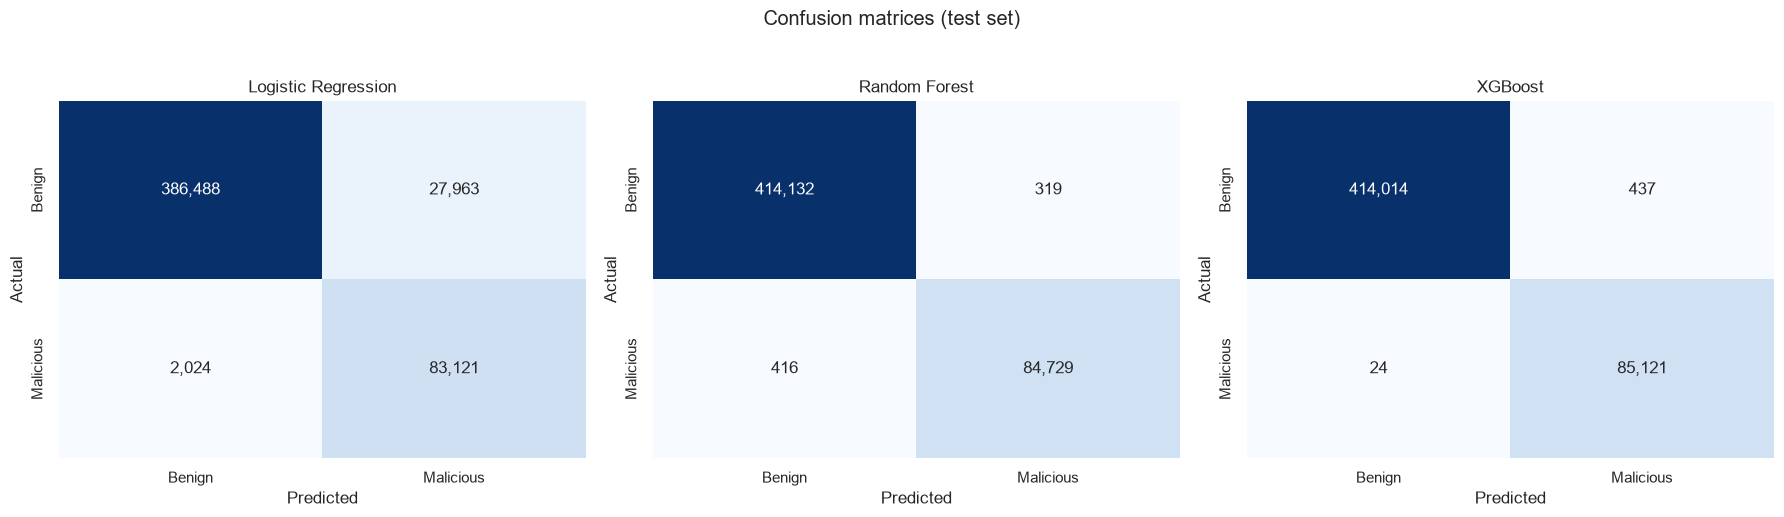

In [12]:
fig, axes = plt.subplots(1, len(trained), figsize=(6 * len(trained), 5))
if len(trained) == 1:
    axes = [axes]

for ax, (name, info) in zip(axes, trained.items()):
    cm = confusion_matrix(y_test, info["y_pred"])
    sns.heatmap(
        cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion matrices (test set)", y=1.03)
plt.tight_layout()
plt.show()

## 10. ROC and precision-recall curves

These curves show how each model's **confidence scores** trade off true-positive rate vs. false-positive rate (ROC) and precision vs. recall (PR) as we slide the decision threshold. The PR curve is particularly informative on imbalanced data like this.

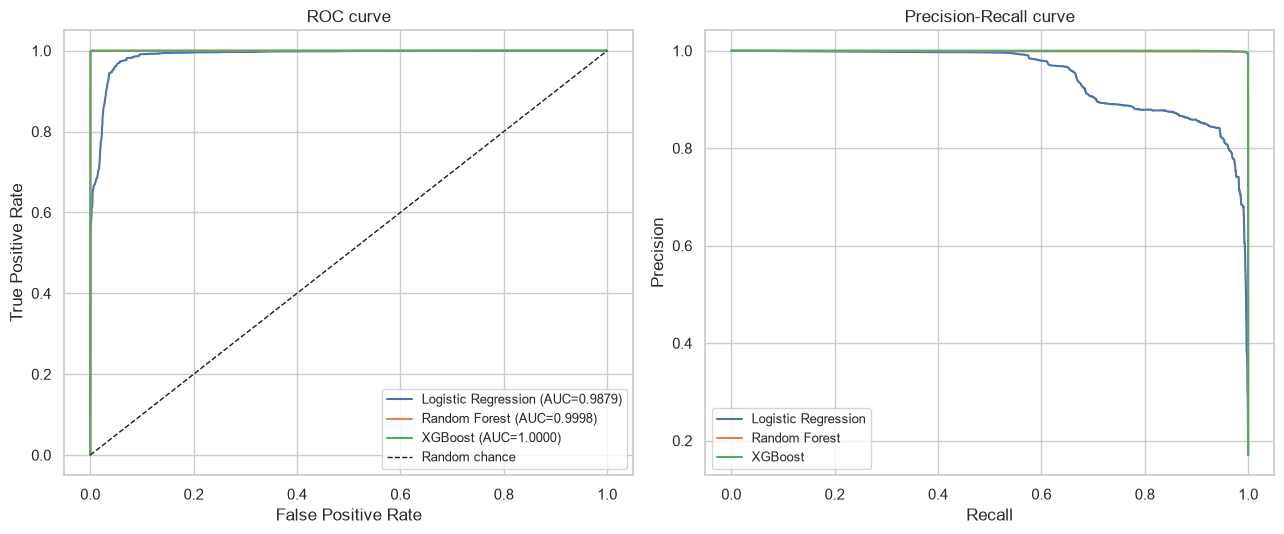

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

for name, info in trained.items():
    fpr, tpr, _ = roc_curve(y_test, info["y_proba"])
    ax1.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, info['y_proba']):.4f})")

    prec, rec, _ = precision_recall_curve(y_test, info["y_proba"])
    ax2.plot(rec, prec, label=name)

ax1.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random chance")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC curve")
ax1.legend(loc="lower right", fontsize=9)

ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall curve")
ax2.legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()

## 11. Model comparison table

A single table to compare all three models side by side and pick a winner.

In [14]:
comparison_df = pd.DataFrame(metrics_rows).set_index("Model").sort_values("F1", ascending=False)
display(comparison_df.style.format({
    "Accuracy": "{:.4%}", "Precision": "{:.4%}", "Recall": "{:.4%}",
    "F1": "{:.4%}", "ROC-AUC": "{:.4%}", "Train time (s)": "{:.1f}",
}).background_gradient(subset=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"], cmap="Greens"))

BEST_MODEL_NAME = comparison_df["F1"].idxmax()
print(f"\nBest model by F1 score: {BEST_MODEL_NAME}")

,Accuracy,Precision,Recall,F1,ROC-AUC,Train time (s)
Model,,,,,,
XGBoost,99.9077%,99.4892%,99.9718%,99.7299%,99.9981%,515.3
Random Forest,99.8529%,99.6249%,99.5114%,99.5681%,99.9802%,1417.1
Logistic Regression,93.9978%,74.8272%,97.6229%,84.7184%,98.7904%,73.0



Best model by F1 score: XGBoost


## 12. Feature importance

Both tree-based models expose a built-in importance score: roughly, "how much did splitting on this feature reduce impurity, averaged across all trees." This is fast to compute but can be biased toward high-cardinality numeric features, so we'll cross-check it with permutation importance and SHAP below.

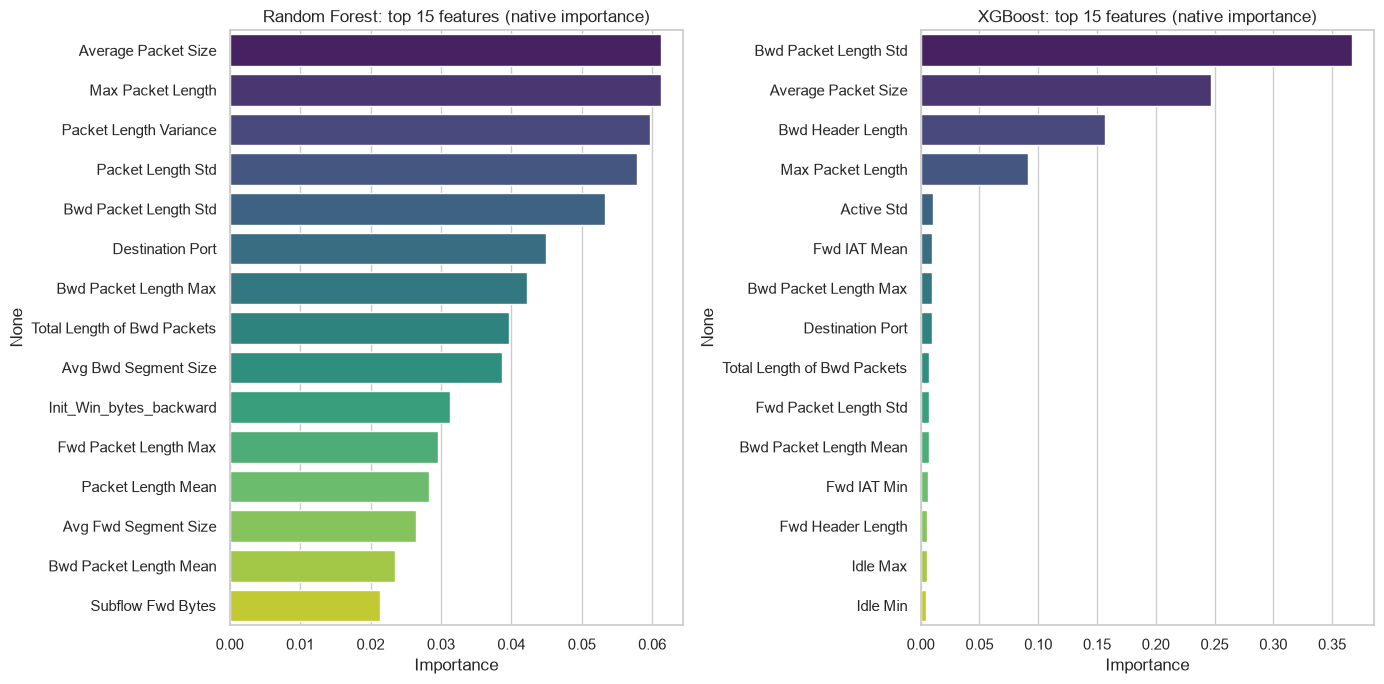

In [15]:
tree_models = {n: i for n, i in trained.items() if hasattr(i["model"], "feature_importances_")}

fig, axes = plt.subplots(1, len(tree_models), figsize=(7 * len(tree_models), 7))
if len(tree_models) == 1:
    axes = [axes]

for ax, (name, info) in zip(axes, tree_models.items()):
    importances = pd.Series(info["model"].feature_importances_, index=X.columns)
    top = importances.sort_values(ascending=False).head(15)
    sns.barplot(x=top.values, y=top.index, hue=top.index, palette="viridis", legend=False, ax=ax)
    ax.set_title(f"{name}: top 15 features (native importance)")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

## 13. Permutation importance (model-agnostic cross-check)

Native importance can be misleading, so we cross-check with **permutation importance**: shuffle one feature's values at a time and measure how much the model's F1 score drops. A feature that matters a lot will hurt performance a lot when scrambled. This works for *any* model (including Logistic Regression) and is computed on a random sample of the test set for speed.

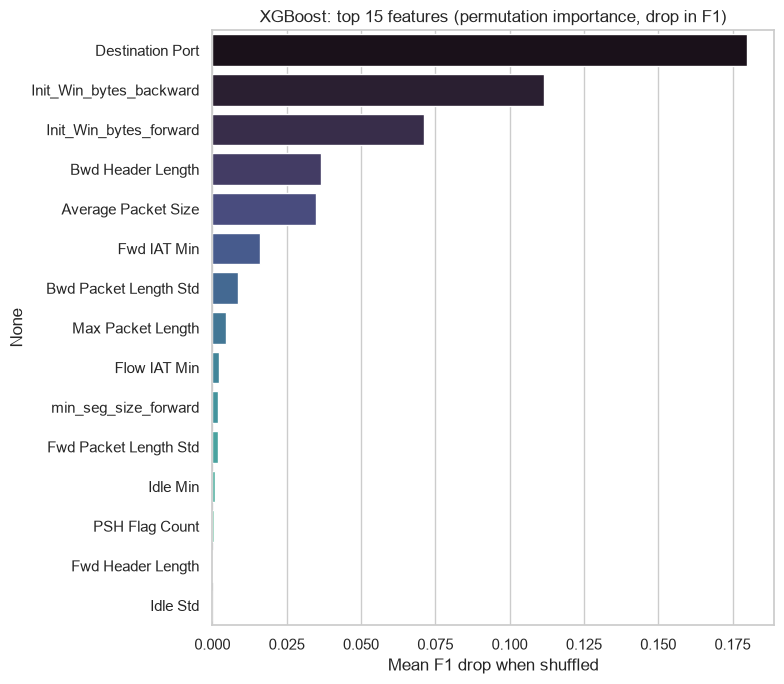

In [16]:
from sklearn.inspection import permutation_importance

best_info = trained[BEST_MODEL_NAME]
X_eval = pd.DataFrame(X_test_scaled, columns=X.columns) if best_info["uses_scaled"] else X_test
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_eval), size=5000, replace=False)

perm_result = permutation_importance(
    best_info["model"], X_eval.iloc[sample_idx], y_test.values[sample_idx],
    scoring="f1", n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1,
)
perm_importances = pd.Series(perm_result.importances_mean, index=X.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(x=perm_importances.values, y=perm_importances.index, hue=perm_importances.index,
            palette="mako", legend=False, ax=ax)
ax.set_title(f"{BEST_MODEL_NAME}: top 15 features (permutation importance, drop in F1)")
ax.set_xlabel("Mean F1 drop when shuffled")
plt.tight_layout()
plt.show()

## 14. SHAP explainability

SHAP (SHapley Additive exPlanations) goes further than a single importance score: for every individual prediction, it attributes "how many percentage points did this feature push the prediction toward Malicious vs. Benign." The **beeswarm plot** shows, for the top features, how each feature's value (color) relates to its impact on the prediction (x-axis) across many individual flows — e.g. "high values of this feature push predictions toward Malicious." The **bar plot** collapses that to one number per feature (mean absolute impact), similar to feature importance but computed consistently with game-theoretic guarantees.

We use a random sample of the test set (not the full 500k+ rows) purely for speed — SHAP is computationally expensive per-sample.

In [ ]:
import shap

rng = np.random.RandomState(RANDOM_STATE)
sample_idx_shap = rng.choice(len(X_test), size=2000, replace=False)

if hasattr(best_info["model"], "feature_importances_"):
    # Tree-based model: TreeExplainer's "tree_path_dependent" mode needs no background
    # dataset and (unlike the interventional mode) supports XGBoost's hist-grown trees.
    X_shap_sample = X_test.iloc[sample_idx_shap]
    explainer = shap.TreeExplainer(best_info["model"])
else:
    background_idx = rng.choice(len(X_train_scaled), size=100, replace=False)
    X_background = pd.DataFrame(X_train_scaled[background_idx], columns=X.columns)
    X_shap_sample = pd.DataFrame(X_test_scaled[sample_idx_shap], columns=X.columns)
    explainer = shap.Explainer(best_info["model"], X_background)

shap_exp = explainer(X_shap_sample)

# Binary classifiers can produce a 3D Explanation (samples, features, classes) — keep the "Malicious" class slice
if shap_exp.values.ndim == 3:
    shap_exp = shap_exp[..., 1]

shap.plots.beeswarm(shap_exp, max_display=15, show=False)
plt.title(f"{BEST_MODEL_NAME}: SHAP summary — impact on 'Malicious' prediction")
plt.tight_layout()
plt.show()

In [ ]:
shap.plots.bar(shap_exp, max_display=15, show=False)
plt.title(f"{BEST_MODEL_NAME}: mean |SHAP value| by feature")
plt.tight_layout()
plt.show()

## 15. Predictions with confidence / risk scores

The model's `predict_proba` output is a probability that a flow is malicious — we treat this as a **confidence score** and bucket it into a **risk level** for a more analyst-friendly view. Thresholds below are a reasonable starting point; in a real deployment you'd tune them against the cost of false alarms vs. missed attacks (see the PR curve above).

In [ ]:
def risk_level(p):
    if p < 0.3:
        return "Low"
    elif p < 0.7:
        return "Medium"
    return "High"

y_proba_best = best_info["y_proba"]
y_pred_best = best_info["y_pred"]

sample_pos = np.random.RandomState(RANDOM_STATE).choice(len(X_test), size=15, replace=False)
sample_test_index = X_test.index[sample_pos]

predictions_df = pd.DataFrame({
    "Original label": df.loc[sample_test_index, "Label"].values,
    "Actual": [CLASS_NAMES[v] for v in y_test.values[sample_pos]],
    "Predicted": [CLASS_NAMES[v] for v in y_pred_best[sample_pos]],
    "Confidence (% Malicious)": (y_proba_best[sample_pos] * 100).round(2),
    "Risk level": [risk_level(p) for p in y_proba_best[sample_pos]],
})
display(predictions_df)

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(x=y_proba_best[y_test.values == 0], bins=50, color="#4C72B0",
             label="Actual: Benign", stat="density", alpha=0.6, ax=ax)
sns.histplot(x=y_proba_best[y_test.values == 1], bins=50, color="#C44E52",
             label="Actual: Malicious", stat="density", alpha=0.6, ax=ax)
ax.set_xlabel("Predicted probability of Malicious (confidence score)")
ax.set_title(f"{BEST_MODEL_NAME}: confidence score distribution by true class")
ax.legend()
plt.tight_layout()
plt.show()

## 16. Save the trained model

We persist the winning model (plus the scaler and feature column order, needed to preprocess any new data identically) to `models/` with `joblib`, so it can be loaded and reused without retraining.

In [ ]:
import joblib

artifact = {
    "model": best_info["model"],
    "model_name": BEST_MODEL_NAME,
    "uses_scaled": best_info["uses_scaled"],
    "scaler": scaler,
    "feature_columns": list(X.columns),
    "class_names": CLASS_NAMES,
}

out_path = MODELS_DIR / "intrusion_detector.joblib"
joblib.dump(artifact, out_path)
print(f"Saved best model ({BEST_MODEL_NAME}) to {out_path}")
print(f"File size: {out_path.stat().st_size / 1e6:.1f} MB")

## Summary

- Combined ~2.8M flow records from all 8 CIC-IDS2017 capture files, cleaned inf/NaN values and duplicates.
- Framed the task as binary classification: **Benign vs. Malicious** network flows.
- Trained and compared three models (Logistic Regression, Random Forest, XGBoost) with class weighting for the ~80/20 imbalance.
- Evaluated with accuracy, precision, recall, F1, ROC-AUC, confusion matrices, and ROC/PR curves.
- Explained the winning model with native feature importance, permutation importance, and SHAP.
- Produced example predictions with confidence scores and Low/Medium/High risk buckets.
- Saved the winning model to `models/intrusion_detector.joblib` for reuse.

### Ideas to take this further
- Try per-attack-type (multi-class) classification instead of collapsing everything into "Malicious" — e.g., can the model tell DDoS apart from PortScan?
- Tune the decision threshold using the PR curve to hit a specific recall target (e.g., "catch 99% of attacks, accept the resulting false-positive rate").
- Cross-validate instead of a single train/test split to get a sense of variance in the metrics.
- Try hyperparameter tuning (e.g. `RandomizedSearchCV`) on the winning model.